In [1]:
import pandas as pd

In [3]:
df=pd.read_excel("../data/Telco_customer_churn.xlsx")

In [4]:
df.shape # Output: (7043, 21) aana chahiye
df.info() # dtypes check karo
df.head() # pehli 5 rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [11]:
# Step 1: Column names clean karo
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())

# Step 2: Ab Total Charges use karo, TotalCharges nahi
# Problem: Total Charges me blank spaces ' ' hai jaha null hona chahiye tha
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Ab 11 nulls aa gaye honge. Median se fill karo
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

# Step 3: Verify karo
df.info() # Ab Total Charges float64 hona chahiye
print(df.isnull().sum()) # Sab 0 aana chahiye

Columns: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat 

C:\Users\deepa\AppData\Local\Temp\ipykernel_6268\2480268818.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)


Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


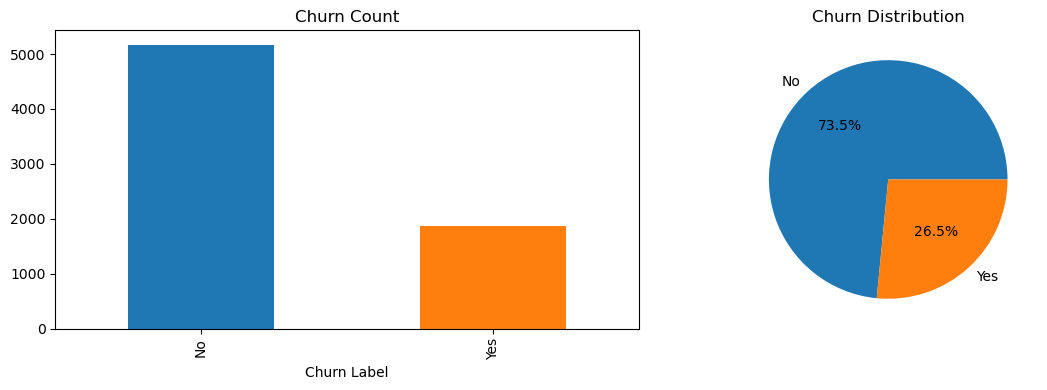

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

churn_rate = df['Churn Label'].value_counts(normalize=True) * 100
print(churn_rate) # Yes/No ka % milega

fig, ax = plt.subplots(1,2, figsize=(12,4))
df['Churn Label'].value_counts().plot(kind='bar', ax=ax[0], color=['#1f77b4','#ff7f0e'])
ax[0].set_title('Churn Count')
ax[0].set_xlabel('Churn Label')

df['Churn Label'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Churn Distribution')
ax[1].set_ylabel('')
plt.tight_layout()
plt.savefig('../reports/churn_distribution.png')
plt.show()

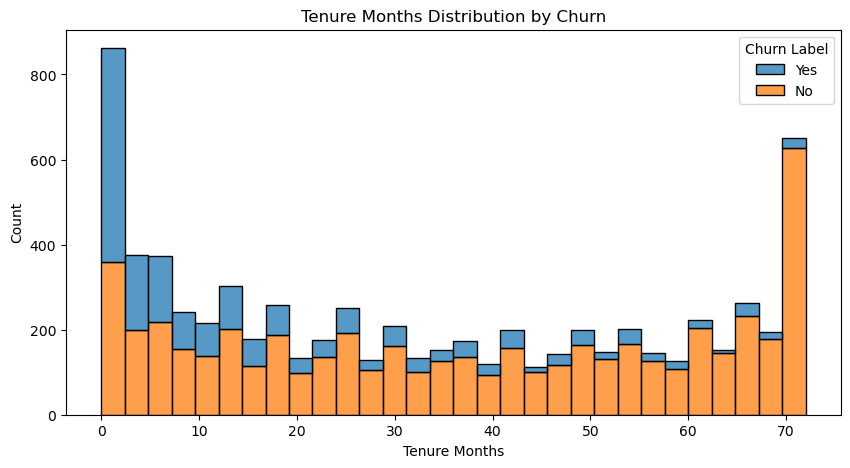

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Tenure Months', hue='Churn Label', multiple='stack', bins=30)
plt.title('Tenure Months Distribution by Churn')
plt.savefig('../reports/tenure_churn.png')
plt.show()

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Label, dtype: float64


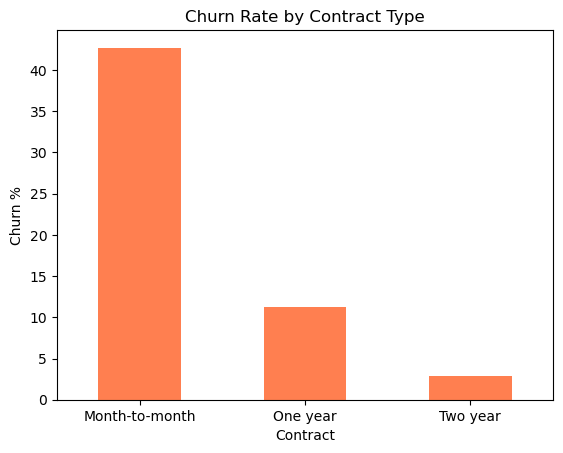

In [15]:
contract_churn = df.groupby('Contract')['Churn Label'].apply(lambda x: (x=='Yes').mean()*100)
print(contract_churn.sort_values(ascending=False))

contract_churn.plot(kind='bar', color='coral')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn %')
plt.xticks(rotation=0)
plt.savefig('../reports/contract_churn.png')
plt.show()

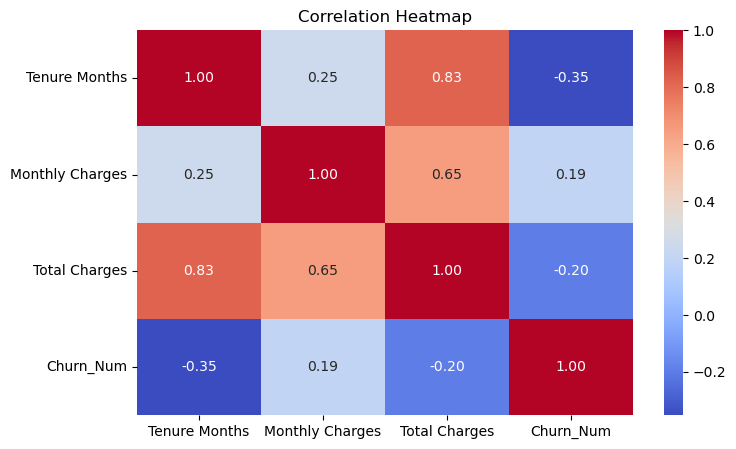

In [16]:
df['Churn_Num'] = df['Churn Label'].map({'Yes':1, 'No':0})

plt.figure(figsize=(8,5))
sns.heatmap(df[['Tenure Months','Monthly Charges','Total Charges','Churn_Num']].corr(), 
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('../reports/correlation.png')
plt.show()

In [ ]:
## EDA Key Insights - Week 2
1. **Class Imbalance**: Churn rate 26.5%. Model me `class_weight='balanced'` use karna padega.
2. **Contract Type Impact**: Month-to-month = 43% churn vs Two year = 3%. Sabse bada driver.
3. **Tenure Effect**: 0-12 months tenure me sabse zyada risk.
4. **Total Charges Fixed**: 11 nulls the, median se fill kiya. Ab float64 hai.